# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Complex Analytics using Pyspark

## Problem Statement

Perform complex analytics on a network intrusion dataset using Pyspark

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the data using Pyspark
* implement RDD based operations on the data
* derive insights from the complex data

### Dataset

The dataset chosen for this mini-project is a [10% subset](https://www.kdd.org/kdd-cup/view/kdd-cup-1999/Data) of the **[KDD Cup 1999 dataset](http://kdd.ics.uci.edu/databases/kddcup99/task.html)** (Computer network intrusion detection). This is the dataset used for the Third International Knowledge Discovery and Data Mining Tools Competition. The competition task was to build a network intrusion detector, a predictive model capable of distinguishing between ``bad`` connections, called intrusions or attacks, and ``good`` normal connections. This database contains a standard set of data to be audited, which includes a wide variety of intrusions simulated in a military network environment.

## Information

Since 1999, KDD’99 has been the most widely used data set for the evaluation of anomaly detection methods. This data set is prepared by S. J. Stolfo and is built based on the data captured in DARPA’98 IDS evaluation program. DARPA’98 is about 4 gigabytes of compressed raw (binary) tcpdump data of 7 weeks of network traffic, which can be processed into about 5 million connection
records, each with about 100 bytes. KDD dataset consists of approximately 4,900,000 single connection vectors each of which contains 41 features and is labeled as either normal or an attack, with exactly one specific attack type. The simulated attacks fall into one of the following four categories:

* Denial of Service Attack (DoS): making some computing or memory resources too busy so that they deny legitimate users access to these resources.
* User to Root Attack (U2R): unauthorized access from a remote machine according to exploit machine's vulnerabilities.
* Remote to Local Attack (R2L): unauthorized access to local super user (root) privileges using system's susceptibility.
* Probing Attack: host and port scans as precursors to other attacks. An attacker scans a network to gather information or find known vulnerabilities.

KDD’99 features can be classified into three groups:

1) Basic features: this category encapsulates all the attributes that can be extracted from a TCP/IP connection. Most of these features leading to an implicit delay in detection.

2) Traffic features: this category includes features that are computed with respect to a window interval and is divided into two groups:

  * "same host" features

  * "same service" features

3) Content features: unlike most of the DoS and Probing attacks, the R2L and U2R attacks don’t have any intrusion frequent sequential patterns. This is because the DoS and Probing attacks involve many connections to some host(s) in a very short period of time, however the R2L and U2R attacks are embedded in the data portions of the packets, and normally involve only a single connection. To detect these kinds of attacks, we need some features to be able to look for suspicious behavior in the data portion, e.g., the number of failed login attempts. These features are called content features.

## Grading = 10 Points

In [1]:
#@title Install packages and Download Dataset
!pip -qq install pyspark
# Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/kddcup.data_10_percent.gz
# Download feature names
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/kddcup.names
print("Successfully Installed packages and downloaded datasets!")

Successfully Installed packages and downloaded datasets!


### Create Spark Session and load the data (1 point)

#### Import required packages

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.mllib.stat import Statistics
from pyspark.sql.functions import col
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from operator import add

#### Create a Spark session

A Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0 (Instead of having various contexts, everything is encapsulated in a Spark session)

In [3]:
# Start spark session
# YOUR CODE HERE
spark = SparkSession.builder.appName('KDD99').getOrCreate()

In [4]:
spark

#### Creating an RDD from a File

The most common way of creating an RDD is to load it from a file. Notice that Spark's textFile can handle compressed files directly.

In [5]:
# YOUR CODE HERE to access sparkContext from sparkSession instance.
sc = spark.sparkContext

Load the dataset and show the top 10 records

Hint: sparkContext.textFile()

In [6]:
filePath = "/content/kddcup.data_10_percent.gz"
# YOUR CODE HERE

kdd99_rdd = sc.textFile(filePath)
kdd99_rdd.take(10)

['0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,19,19,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,29,29,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,39,39,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,49,49,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,59,59,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,212,1940,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.00,0.00,0.00,0.00,1.00,0.00,

### RDD Basic Operations (4 points)

#### Convert the data to CSV format (list of elements).

To create a Dataframe using the RDD file, convert each row into a list by splitting with a comma (,)

Hint: `map()` and `split()`

In [7]:
# YOUR CODE HERE

kdd99_rdd_split = kdd99_rdd.map(lambda x: x.split(','))
kdd99_df = kdd99_rdd_split.toDF()

In [8]:
# Read the feature names from the kddcup.names file and correct them
with open("/content/kddcup.names", 'r') as f:
    # Exclude lines starting with '|' which are not feature names
    feature_lines = [line.strip() for line in f if not line.startswith('|')]

# The first line contains attack types, not features, so skip it.
# Extract feature names by splitting each line at ':' and taking the first part.
feature_names = [line.split(':')[0] for line in feature_lines[1:]]

# The last column is the label, which is 'intrusion_type'
feature_names.append('intrusion_type')

# Check the number of extracted feature names
print(f"Number of extracted feature names: {len(feature_names)}")
print(f"Number of columns in DataFrame: {len(kdd99_df.columns)}")

# Rename the columns in the DataFrame if the counts match
if len(feature_names) == len(kdd99_df.columns):
    kdd99_df = kdd99_df.toDF(*feature_names)
    print("DataFrame columns renamed successfully.")
    kdd99_df.show(5)
else:
    print("Error: Number of extracted feature names does not match the number of columns in the DataFrame.")
    print("Extracted names:", feature_names)

Number of extracted feature names: 42
Number of columns in DataFrame: 42
DataFrame columns renamed successfully.
+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+--------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|

In [9]:
kdd99_df.show(10)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+--------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate|

Count how many interactions are normal and attacked in the dataset.

Hint: apply `filter` on each row, except the rows with 'normal.', all the remaining values are attacked.

In [10]:
# YOUR CODE HERE

attack_rdd = kdd99_df.filter(col("intrusion_type") != 'normal.')
attack_count = attack_rdd.count()
attack_count

396743

#### Protocol and Service combinations using Cartesian product

We can compute the Cartesian product between two RDDs by using the Cartesian transformation. It returns all possible pairs of elements between two RDDs. In our case, we will use it to generate all the possible combinations between Service and Protocol in our network interactions.

First of all, isolate each collection of values in two separate RDDs. For that use `distinct` on the CSV-parsed dataset. From the dataset description, we know that protocol is the second column and service is the third.

In [11]:
# YOUR CODE HERE

protocol_rdd = kdd99_rdd_split.map(lambda x: x[1]).distinct()
service_rdd = kdd99_rdd_split.map(lambda x: x[2]).distinct()

In [17]:
protocol_rdd.take(10)

['tcp', 'udp', 'icmp']

In [18]:
service_rdd.take(50)

['http',
 'smtp',
 'finger',
 'domain_u',
 'auth',
 'telnet',
 'ftp',
 'eco_i',
 'ntp_u',
 'ecr_i',
 'other',
 'private',
 'pop_3',
 'ftp_data',
 'rje',
 'time',
 'mtp',
 'link',
 'remote_job',
 'gopher',
 'ssh',
 'name',
 'whois',
 'domain',
 'login',
 'imap4',
 'daytime',
 'ctf',
 'nntp',
 'shell',
 'IRC',
 'nnsp',
 'http_443',
 'exec',
 'printer',
 'efs',
 'courier',
 'uucp',
 'klogin',
 'kshell',
 'echo',
 'discard',
 'systat',
 'supdup',
 'iso_tsap',
 'hostnames',
 'csnet_ns',
 'pop_2',
 'sunrpc',
 'uucp_path']

Now let's do the Cartesian product

Hint: [Cartesian](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.cartesian.html#:~:text=Return%20the%20Cartesian%20product%20of,and%20b%20is%20in%20other%20.)

In [14]:
# YOUR CODE HERE
product = protocol_rdd.cartesian(service_rdd).collect()

In [15]:
product

[('tcp', 'http'),
 ('tcp', 'smtp'),
 ('tcp', 'finger'),
 ('tcp', 'domain_u'),
 ('tcp', 'auth'),
 ('tcp', 'telnet'),
 ('tcp', 'ftp'),
 ('tcp', 'eco_i'),
 ('tcp', 'ntp_u'),
 ('tcp', 'ecr_i'),
 ('tcp', 'other'),
 ('tcp', 'private'),
 ('tcp', 'pop_3'),
 ('tcp', 'ftp_data'),
 ('tcp', 'rje'),
 ('tcp', 'time'),
 ('tcp', 'mtp'),
 ('tcp', 'link'),
 ('tcp', 'remote_job'),
 ('tcp', 'gopher'),
 ('tcp', 'ssh'),
 ('tcp', 'name'),
 ('tcp', 'whois'),
 ('tcp', 'domain'),
 ('tcp', 'login'),
 ('tcp', 'imap4'),
 ('tcp', 'daytime'),
 ('tcp', 'ctf'),
 ('tcp', 'nntp'),
 ('tcp', 'shell'),
 ('tcp', 'IRC'),
 ('tcp', 'nnsp'),
 ('tcp', 'http_443'),
 ('tcp', 'exec'),
 ('tcp', 'printer'),
 ('tcp', 'efs'),
 ('tcp', 'courier'),
 ('tcp', 'uucp'),
 ('tcp', 'klogin'),
 ('tcp', 'kshell'),
 ('tcp', 'echo'),
 ('tcp', 'discard'),
 ('tcp', 'systat'),
 ('tcp', 'supdup'),
 ('tcp', 'iso_tsap'),
 ('tcp', 'hostnames'),
 ('tcp', 'csnet_ns'),
 ('tcp', 'pop_2'),
 ('tcp', 'sunrpc'),
 ('tcp', 'uucp_path'),
 ('tcp', 'netbios_ns'),
 ('t

#### Inspecting interaction duration

select the total duration of interactions for normal and attack intrusion types.
* Use the above filtered normal and attacked data and convert the duration column to integer type using `map()`
* get the sum of duration by applying `reduce` on both the data using add operator
* find the mean of duration by dividing the sum with count

Hint: [reduce()](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.reduce.html)

In [19]:
# YOUR CODE HERE

normal_rdd = kdd99_df.filter(col("intrusion_type") == 'normal.').rdd

# Convert duration to integer
normal_duration = normal_rdd.map(lambda x: int(x['duration']))
attack_duration = attack_rdd.rdd.map(lambda x: int(x['duration']))

In [20]:
# Get the sum of duration for normal and attacked connections
normal_duration_sum = normal_duration.reduce(add)
attack_duration_sum = attack_duration.reduce(add)

print(f"Total duration for normal connections: {normal_duration_sum}")
print(f"Total duration for attacked connections: {attack_duration_sum}")

Total duration for normal connections: 21075991
Total duration for attacked connections: 2626792


In [21]:
# Find the mean duration for normal and attacked connections
normal_duration_mean = normal_duration_sum / normal_duration.count()
attack_duration_mean = attack_duration_sum / attack_duration.count()

print(f"Mean duration for normal connections: {normal_duration_mean}")
print(f"Mean duration for attacked connections: {attack_duration_mean}")

Mean duration for normal connections: 216.65732231336992
Mean duration for attacked connections: 6.620890601724542


#### Data aggregation with key/value pair RDDs

We can use all the transformations and actions available for normal RDDs with key/value pair RDDs. We just need to make the functions work with pair elements.

* create a key/value pair of intrusion type and duration
* calculate the total duration of each intrusion type using `reduceByKey()`

In [ ]:
# create a key/value pair of intrusion type and duration
intrusion_duration_rdd = normal_rdd.map(lambda x: (x['intrusion_type'], int(x['duration'])))

# calculate the total duration of each intrusion type using reduceByKey()
total_duration_by_type = intrusion_duration_rdd.reduceByKey(add)

# Print the results
for intrusion_type, total_duration in total_duration_by_type.collect():
    print(f"Total duration for {intrusion_type}: {total_duration}")

Total duration for normal.: 21075991


### Create a DataFrame with the header as features (2 points)

* Read the features (*kddcup.names*) and preprocess.

    Hints:
    - Each feature description appears row-wise in *kddcup.names*
    - The first row consists of distinct values of intrusion_types
    - Add or move the *intrusion_types* column name to the last, to align with the data.
    - Each feature is represented as *feature_name*: *type*, remove *type* after colon (:)

In [ ]:
# Read the feature names from the kddcup.names file
with open("/content/kddcup.names", 'r') as f:
    feature_lines = [line.strip() for line in f if not line.startswith('|')]

# The first line contains attack types, not features, so skip it.
# Extract feature names by splitting each line at ':' and taking the first part.
feature_names = [line.split(':')[0] for line in feature_lines[1:]]

# Add the 'intrusion_type' column name at the end
feature_names.append('intrusion_type')

print("Preprocessed feature names:", feature_names)

Preprocessed feature names: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'intrusion_type']


* Create a dataframe with the data and headers as preprocessed feature names

In [ ]:
# YOUR CODE HERE
kdd99_df.show(5)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+--------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate|

#### What is the count of each protocol type?

Hint: apply `groupby` on protocol_type and count the records

In [ ]:
# YOUR CODE HERE
protocol_count = kdd99_df.groupBy('protocol_type').count()
protocol_count.show()

+-------------+------+
|protocol_type| count|
+-------------+------+
|          tcp|190065|
|          udp| 20354|
|         icmp|283602|
+-------------+------+



#### Register the DataFrame as a temporary table and extract the data using queries

Hint: [registerTempTable](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.registerTempTable.html)

In [ ]:
# YOUR CODE HERE
kdd99_df.createOrReplaceTempView('kdd_intrusion_data')

* query to extract the label and their frequencies

 Hint: `SQLContext.sql(query)`

In [ ]:
# YOUR CODE HERE
query = "SELECT intrusion_type, COUNT(*) AS frequency FROM kdd_intrusion_data GROUP BY intrusion_type"
result = spark.sql(query)
result.show()

+----------------+---------+
|  intrusion_type|frequency|
+----------------+---------+
|    warezmaster.|       20|
|          smurf.|   280790|
|            pod.|      264|
|           imap.|       12|
|           nmap.|      231|
|   guess_passwd.|       53|
|        ipsweep.|     1247|
|      portsweep.|     1040|
|          satan.|     1589|
|           land.|       21|
|     loadmodule.|        9|
|      ftp_write.|        8|
|buffer_overflow.|       30|
|        rootkit.|       10|
|    warezclient.|     1020|
|       teardrop.|      979|
|           perl.|        3|
|            phf.|        4|
|       multihop.|        7|
|        neptune.|   107201|
+----------------+---------+
only showing top 20 rows



* select the distinct protocol types with their count of transactions which are not normal

In [ ]:
# YOUR CODE HERE

query = "SELECT protocol_type, COUNT(*) AS frequency FROM kdd_intrusion_data WHERE intrusion_type != 'normal.' GROUP BY protocol_type"
result = spark.sql(query)
result.show()

+-------------+---------+
|protocol_type|frequency|
+-------------+---------+
|          tcp|   113252|
|          udp|     1177|
|         icmp|   282314|
+-------------+---------+



* select count of transactions in each protocol type that lasts more than 1 second (duration > 1000), with no data transfer from destination (dst_bytes == 0)

In [ ]:
# YOUR CODE HERE

query = "SELECT protocol_type, COUNT(*) AS frequency FROM kdd_intrusion_data WHERE duration > 1000 AND dst_bytes == 0 GROUP BY protocol_type"
result = spark.sql(query)
result.show()

+-------------+---------+
|protocol_type|frequency|
+-------------+---------+
|          tcp|      139|
+-------------+---------+



### Find the highly correlated columns (2 points)

* identify the columns which are not integer type and remove those columns
* apply correlation function on the data (Hint: `Statistics.corr()`)
* collect the names of the columns on which correlation is applied
* create a dataframe with correlation matrix with index and columns as names
* get the highly correlated features by considering a correlation value greater than 0.8

    Hint: `np.triu()` , `pd.mask()`

In [ ]:
from pyspark.sql.types import IntegerType, FloatType

# Identify columns that should be numeric but were read as string
numeric_cols_as_string = [col_name for col_name, col_type in kdd99_df.dtypes if col_type == 'string' and col_name not in ['protocol_type', 'service', 'flag', 'intrusion_type']]

# Cast identified columns to FloatType (or IntegerType if appropriate)
kdd99_numeric_df = kdd99_df
for col_name in numeric_cols_as_string:
    kdd99_numeric_df = kdd99_numeric_df.withColumn(col_name, col(col_name).cast(FloatType()))

# Drop the remaining non-numeric columns (protocol_type, service, flag, intrusion_type)
non_numeric_cols = ['protocol_type', 'service', 'flag', 'intrusion_type']
kdd99_numeric_df = kdd99_numeric_df.drop(*non_numeric_cols)

print("DataFrame schema after casting and dropping non-numeric columns:")
kdd99_numeric_df.printSchema()

DataFrame schema after casting and dropping non-numeric columns:
root
 |-- duration: float (nullable = true)
 |-- src_bytes: float (nullable = true)
 |-- dst_bytes: float (nullable = true)
 |-- land: float (nullable = true)
 |-- wrong_fragment: float (nullable = true)
 |-- urgent: float (nullable = true)
 |-- hot: float (nullable = true)
 |-- num_failed_logins: float (nullable = true)
 |-- logged_in: float (nullable = true)
 |-- num_compromised: float (nullable = true)
 |-- root_shell: float (nullable = true)
 |-- su_attempted: float (nullable = true)
 |-- num_root: float (nullable = true)
 |-- num_file_creations: float (nullable = true)
 |-- num_shells: float (nullable = true)
 |-- num_access_files: float (nullable = true)
 |-- num_outbound_cmds: float (nullable = true)
 |-- is_host_login: float (nullable = true)
 |-- is_guest_login: float (nullable = true)
 |-- count: float (nullable = true)
 |-- srv_count: float (nullable = true)
 |-- serror_rate: float (nullable = true)
 |-- srv_se

In [ ]:
# eliminating names of columns having string type
# YOUR CODE HERE

# Done

In [ ]:
# Convert the DataFrame to an RDD of Vectors
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql import Row

assembler = VectorAssembler(inputCols=kdd99_numeric_df.columns, outputCol="features")
vector_df = assembler.transform(kdd99_numeric_df).select("features")

# Calculate the correlation matrix using pyspark.ml.stat.Correlation
correlation_matrix = Correlation.corr(vector_df, "features", method="pearson").head()

# The correlation matrix is in a DenseMatrix object within the result
correlation_matrix_values = correlation_matrix[0].toArray()

# Get the names of the columns on which correlation is applied
column_names = kdd99_numeric_df.columns

# Create a pandas DataFrame with the correlation matrix
correlation_df = pd.DataFrame(correlation_matrix_values, index=column_names, columns=column_names)

print("Correlation Matrix DataFrame:")
display(correlation_df)

Correlation Matrix DataFrame:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
duration,1.000000,0.004258,0.005440,-0.000452,-0.003235,0.003786,0.013213,0.005239,-0.017265,0.058095,...,0.010074,-0.117515,-0.118458,0.406233,0.042642,-0.006983,-0.030400,-0.030612,0.006739,0.010465
src_bytes,0.004258,1.000000,-0.000002,-0.000020,-0.000139,-0.000005,0.004483,-0.000027,0.001701,0.000119,...,-0.001743,-0.003212,-0.002052,0.000578,-0.000724,0.001186,-0.000718,0.001122,-0.000393,0.001328
dst_bytes,0.005440,-0.000002,1.000000,-0.000175,-0.001254,0.016288,0.004365,0.049330,0.047814,0.023298,...,-0.048869,-0.005850,0.007058,-0.005314,-0.020143,0.008707,-0.011334,-0.011235,-0.005000,-0.005471
land,-0.000452,-0.000020,-0.000175,1.000000,-0.000318,-0.000017,-0.000295,-0.000065,-0.002784,-0.000038,...,-0.023671,-0.011587,0.001984,-0.000333,0.003799,0.083320,0.012658,0.007795,-0.001511,-0.001665
wrong_fragment,-0.003235,-0.000139,-0.001254,-0.000318,1.000000,-0.000123,-0.002106,-0.000467,-0.019908,-0.000271,...,-0.005191,-0.058624,-0.054903,0.071857,-0.031803,0.012092,-0.019091,-0.022104,0.029774,-0.011904
urgent,0.003786,-0.000005,0.016288,-0.000017,-0.000123,1.000000,0.000356,0.141996,0.006164,0.014285,...,-0.007139,-0.004540,-0.003279,0.010536,-0.002002,-0.000408,-0.001194,-0.001191,-0.000648,-0.000641
hot,0.013213,0.004483,0.004365,-0.000295,-0.002106,0.000356,1.000000,0.008740,0.105305,0.007348,...,-0.026366,-0.038730,-0.029117,0.001319,-0.052923,-0.004467,-0.019491,-0.020201,-0.006541,-0.007749
num_failed_logins,0.005239,-0.000027,0.049330,-0.000065,-0.000467,0.141996,0.008740,1.000000,-0.001145,0.006907,...,-0.025444,-0.015413,0.000507,0.001017,-0.009565,0.016001,-0.001945,-0.002453,0.024753,0.023584
logged_in,-0.017265,0.001701,0.047814,-0.002784,-0.019908,0.006164,0.105305,-0.001145,1.000000,0.013612,...,-0.621029,0.119315,0.161070,-0.061151,-0.461558,0.140493,-0.190955,-0.191704,-0.090868,-0.087885
num_compromised,0.058095,0.000119,0.023298,-0.000038,-0.000271,0.014285,0.007348,0.006907,0.013612,1.000000,...,-0.008361,-0.004797,-0.002584,0.000359,-0.006715,0.000621,-0.001978,-0.001631,-0.000843,-0.000873


In [ ]:
#  fill the null values with 0
# YOUR CODE HERE
correlation_df.fillna(0, inplace=True)

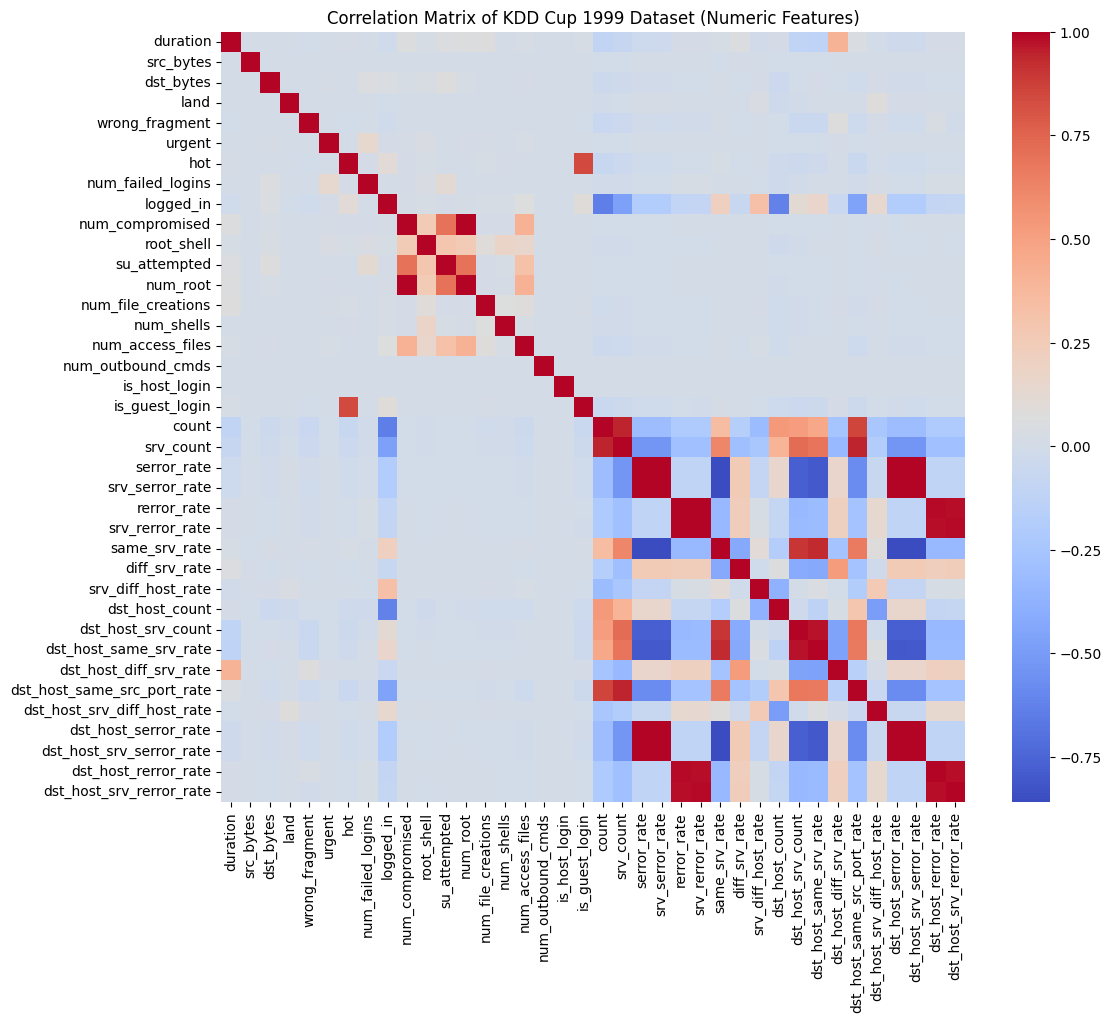

In [ ]:
# Visualize the correlation matrix using seaborn heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of KDD Cup 1999 Dataset (Numeric Features)')
plt.show()

In [ ]:
# Finding features with correlation value more than specified threshold value (bar=0.8)
bar = 0.8

# Create a mask to hide the upper triangle and diagonal
mask = np.triu(np.ones(correlation_df.shape), k=1).astype(bool)

# Get the index and columns from the correlation_df
index = correlation_df.index
columns = correlation_df.columns

# Apply the mask and find highly correlated features
# Convert the nested loops to a dictionary comprehension
highly_correlated_features = {
    (index[i], columns[j]): correlation_matrix_values[i, j]
    for i in range(len(index))
    for j in range(len(columns))
    if mask[i, j] and abs(correlation_matrix_values[i, j]) > bar
}


print(highly_correlated_features)
# # Print the highly correlated features
print("Highly correlated features (correlation > 0.8):")
for (feature1, feature2), correlation_value in highly_correlated_features.items():
    print(f"({feature1}, {feature2}): {correlation_value}")

{('hot', 'is_guest_login'): np.float64(0.8435715365707731), ('num_compromised', 'num_root'): np.float64(0.993827797885562), ('count', 'srv_count'): np.float64(0.9436670688859806), ('count', 'dst_host_same_src_port_rate'): np.float64(0.8605787402054547), ('srv_count', 'dst_host_same_src_port_rate'): np.float64(0.9449263675101385), ('serror_rate', 'srv_serror_rate'): np.float64(0.9983615072759132), ('serror_rate', 'same_srv_rate'): np.float64(-0.8582468733392457), ('serror_rate', 'dst_host_serror_rate'): np.float64(0.9986729680056983), ('serror_rate', 'dst_host_srv_serror_rate'): np.float64(0.9978492485687793), ('srv_serror_rate', 'same_srv_rate'): np.float64(-0.8570596890247689), ('srv_serror_rate', 'dst_host_serror_rate'): np.float64(0.9978353003732233), ('srv_serror_rate', 'dst_host_srv_serror_rate'): np.float64(0.9993041091830381), ('rerror_rate', 'srv_rerror_rate'): np.float64(0.9947309539363997), ('rerror_rate', 'dst_host_rerror_rate'): np.float64(0.9869947925192707), ('rerror_rate

### Analysis report (1 points)

* Find the ratio of attacked transactions vs normal transactions

    Hint: encode instrusion_type column by replacing normal with 1 and all other with 0

* Describe the statistics of attacked and normal transactions
    
    Hint: Min, Max, Mean
    
* Select any two features that influence the intrusion_type and visualize the scatter plot to see the separation of normal and attacked

In [ ]:
from pyspark.sql.functions import when

# Find the ratio of attacked transactions vs normal transactions
# Encode intrusion_type column: normal with 1 and all other with 0
kdd99_df_encoded = kdd99_df.withColumn("is_normal", when(col("intrusion_type") == "normal.", 1).otherwise(0))

# Count normal and attacked transactions
normal_count = kdd99_df_encoded.filter(col("is_normal") == 1).count()
attacked_count = kdd99_df_encoded.filter(col("is_normal") == 0).count()

# Calculate the ratio
total_count = kdd99_df_encoded.count()
ratio_attacked_to_normal = attacked_count / normal_count if normal_count > 0 else float('inf')
ratio_normal_to_total = normal_count / total_count if total_count > 0 else 0
ratio_attacked_to_total = attacked_count / total_count if total_count > 0 else 0

print(f"Normal transactions count: {normal_count}")
print(f"Attacked transactions count: {attacked_count}")
print(f"Ratio of attacked to normal transactions: {ratio_attacked_to_normal}")
print(f"Ratio of normal to total transactions: {ratio_normal_to_total}")
print(f"Ratio of attacked to total transactions: {ratio_attacked_to_total}")

Normal transactions count: 97278
Attacked transactions count: 396743
Ratio of attacked to normal transactions: 4.0784452805361955
Ratio of normal to total transactions: 0.19691065764410826
Ratio of attacked to total transactions: 0.8030893423558918


In [ ]:
from pyspark.sql.types import FloatType

# Separate normal and attacked transactions
normal_df = kdd99_df.filter(col("intrusion_type") == "normal.")
attacked_df = kdd99_df.filter(col("intrusion_type") != "normal.")

# Identify columns that should be numeric but are strings in the original DataFrame
numeric_cols_as_string = [col_name for col_name, col_type in kdd99_df.dtypes if col_type == 'string' and col_name not in ['protocol_type', 'service', 'flag', 'intrusion_type']]

# Cast numeric columns to FloatType for both normal and attacked DataFrames
for col_name in numeric_cols_as_string:
    normal_df = normal_df.withColumn(col_name, col(col_name).cast(FloatType()))
    attacked_df = attacked_df.withColumn(col_name, col(col_name).cast(FloatType()))

# Drop non-numeric columns before describing
non_numeric_cols = ['protocol_type', 'service', 'flag', 'intrusion_type']
normal_numeric_df = normal_df.drop(*non_numeric_cols)
attacked_numeric_df = attacked_df.drop(*non_numeric_cols)


print("Descriptive statistics for normal transactions:")
normal_numeric_df.describe().show()

print("Descriptive statistics for attacked transactions:")
attacked_numeric_df.describe().show()

Descriptive statistics for normal transactions:
+-------+------------------+------------------+-----------------+--------------------+--------------+--------------------+-------------------+--------------------+------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-----------------+-------------+--------------------+------------------+------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+------------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+
|summary|          duration|         src_bytes|        dst_bytes|                land|wrong_fragment|              urgent|                hot|   num_failed

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


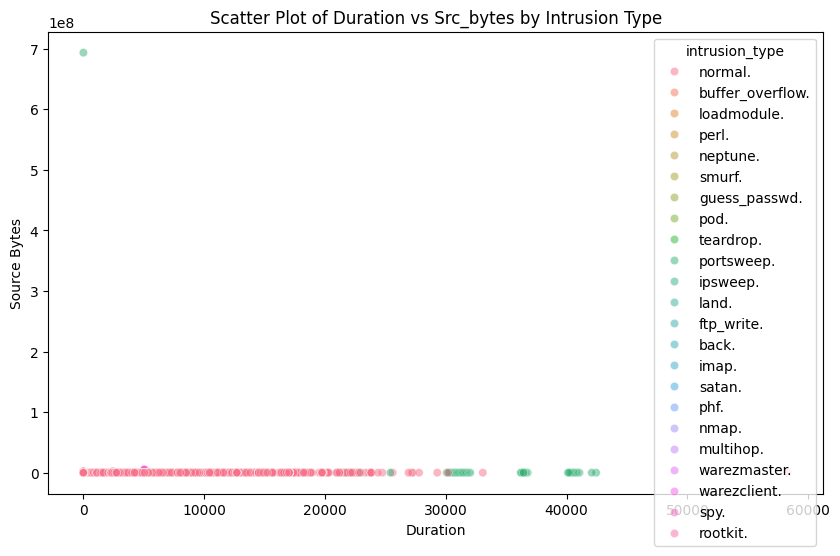

In [ ]:
# Select two features for visualization (e.g., 'duration' and 'src_bytes')

features_to_visualize = ['duration', 'src_bytes', 'intrusion_type']
visualization_df = kdd99_df.select(features_to_visualize)

# Cast the feature columns to FloatType for visualization
visualization_df = visualization_df.withColumn('duration', col('duration').cast(FloatType()))
visualization_df = visualization_df.withColumn('src_bytes', col('src_bytes').cast(FloatType()))


# Convert to pandas DataFrame for visualization
visualization_pandas_df = visualization_df.toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=visualization_pandas_df, x='duration', y='src_bytes', hue='intrusion_type', alpha=0.5)
plt.title('Scatter Plot of Duration vs Src_bytes by Intrusion Type')
plt.xlabel('Duration')
plt.ylabel('Source Bytes')
plt.show()

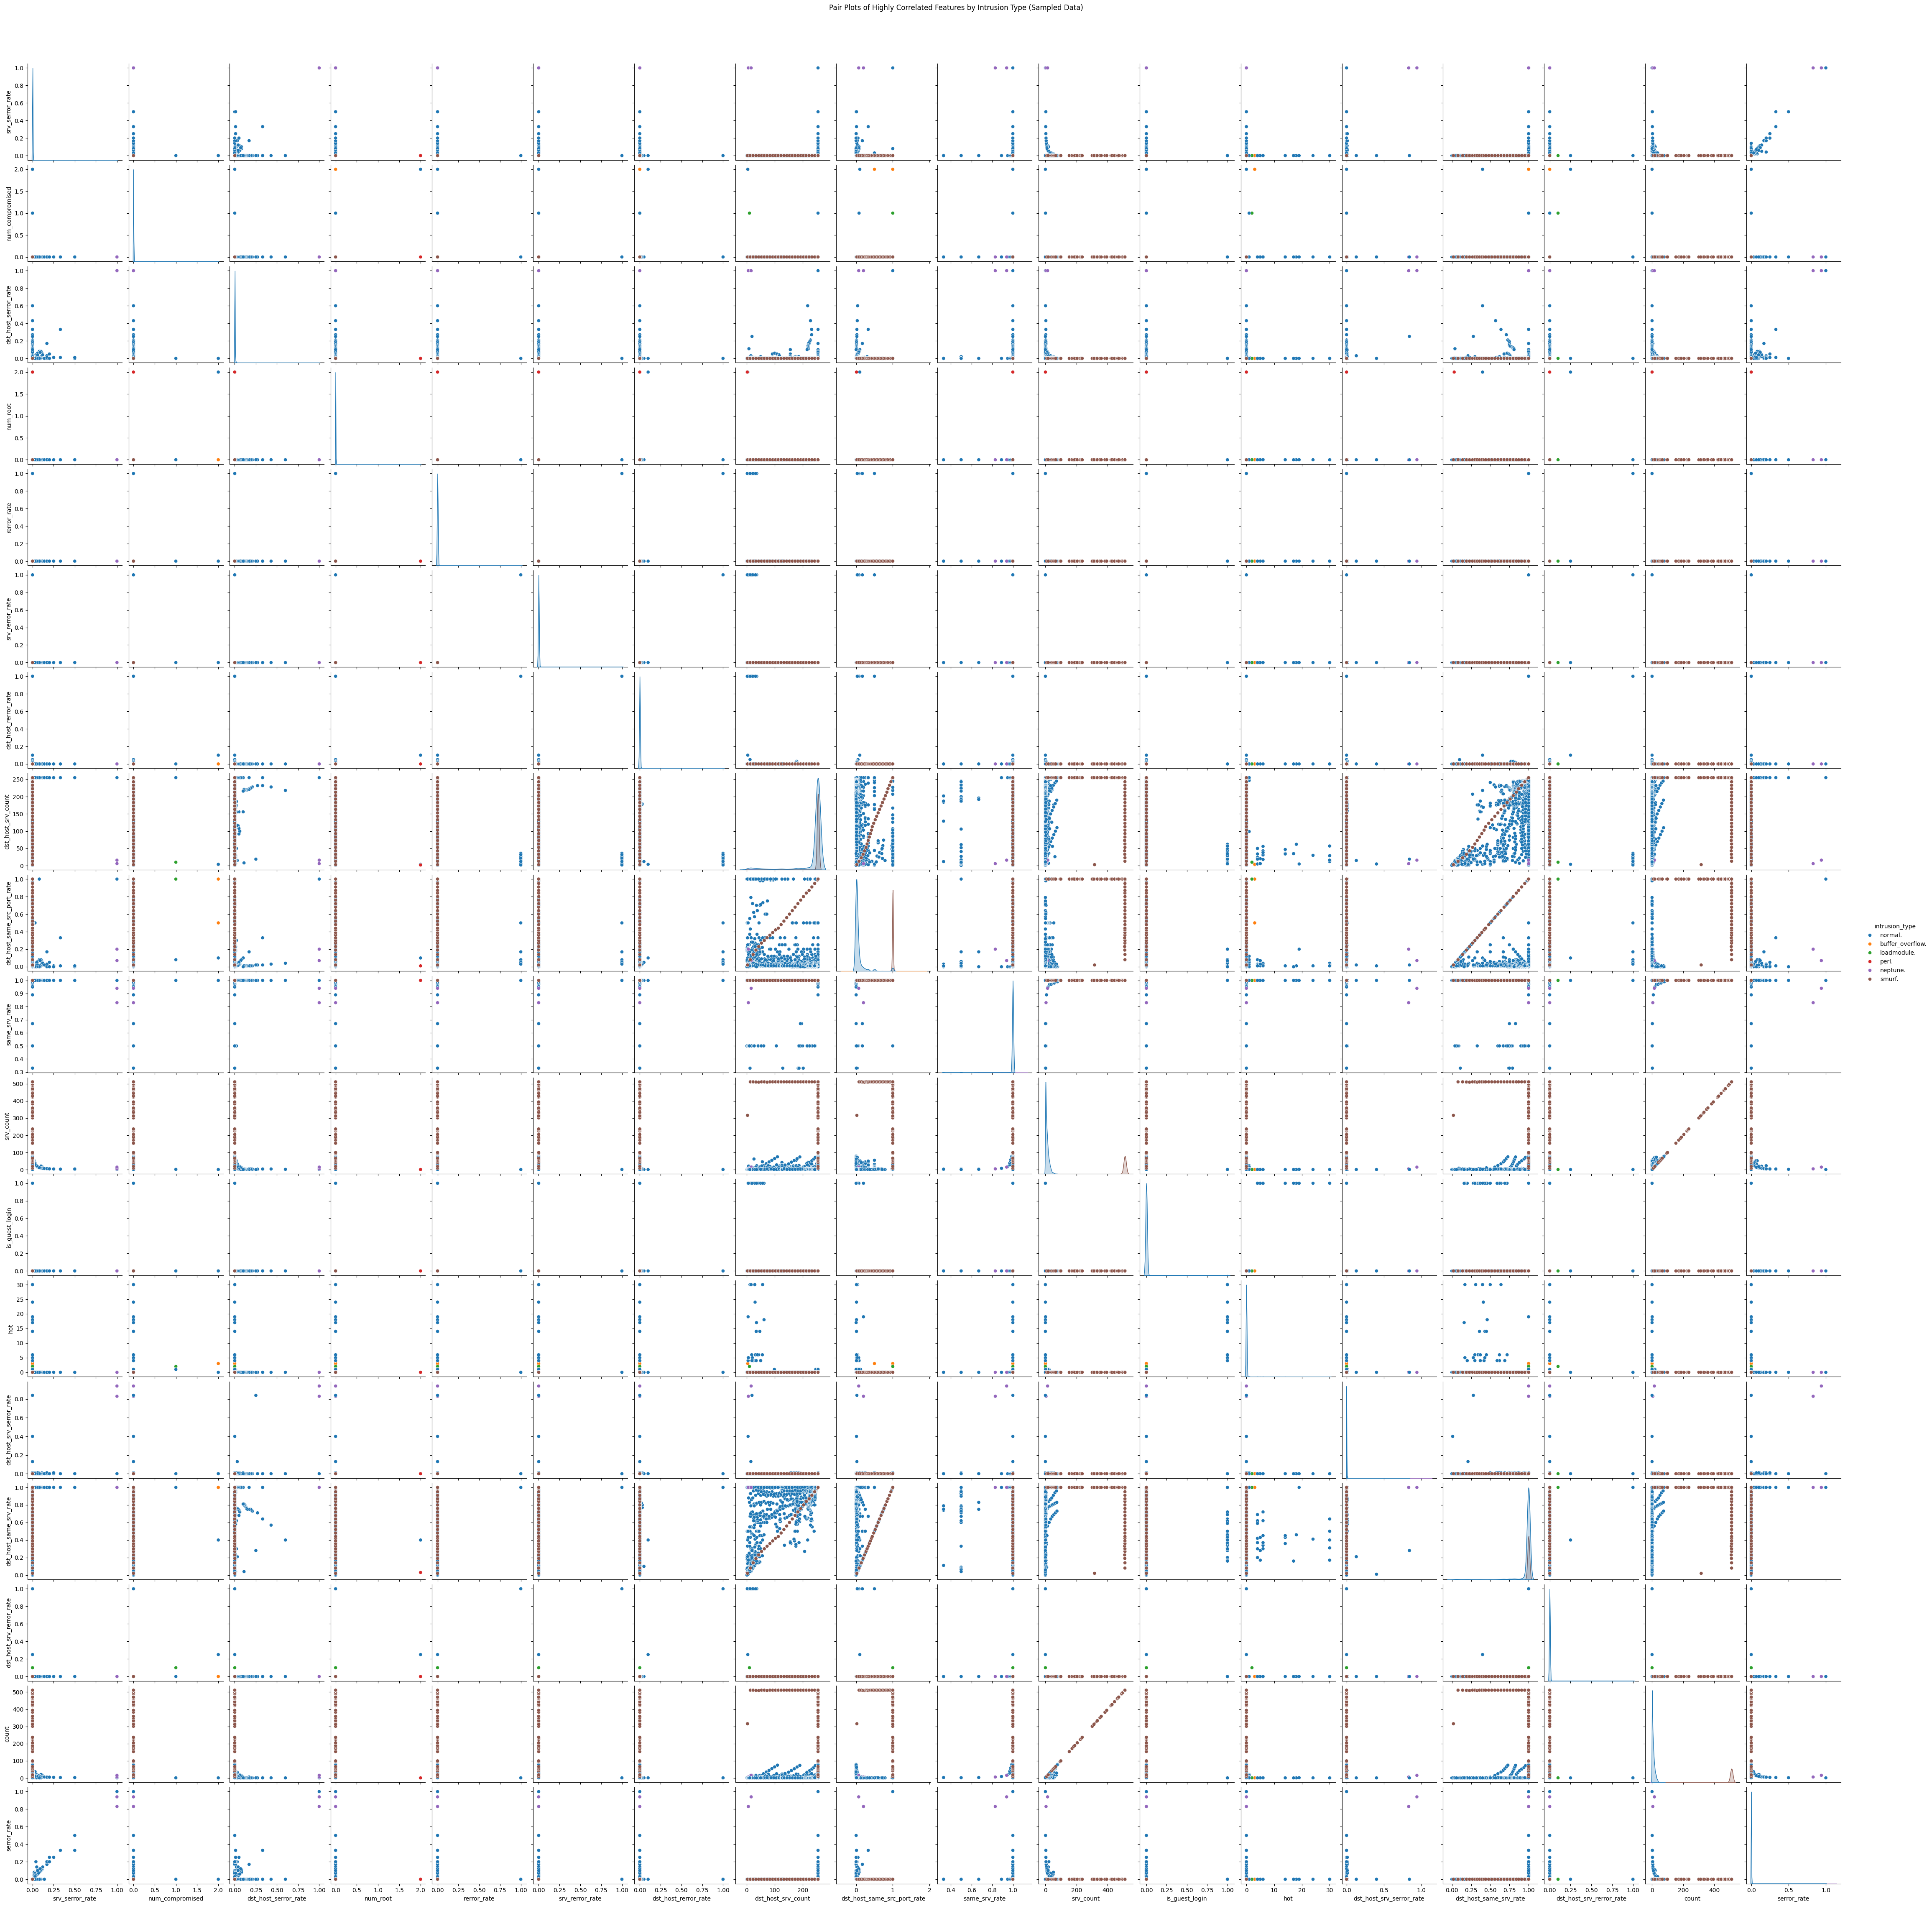

In [ ]:
# Create pair plots for highly correlated features

# Select the highly correlated features from the original DataFrame
# We need the original DataFrame to include the intrusion_type for coloring the plots
highly_correlated_cols = list(set([item for sublist in highly_correlated_features.keys() for item in sublist]))
features_for_pairplot = highly_correlated_cols + ['intrusion_type']

# Ensure all selected columns exist in the original DataFrame
valid_features_for_pairplot = [col for col in features_for_pairplot if col in kdd99_df.columns]

# Select only the relevant columns and cast numeric columns to FloatType
pairplot_df = kdd99_df.select(valid_features_for_pairplot)

numeric_cols_to_cast = [col_name for col_name in highly_correlated_cols if col_name in pairplot_df.columns]
for col_name in numeric_cols_to_cast:
    pairplot_df = pairplot_df.withColumn(col_name, col(col_name).cast(FloatType()))


# Convert to pandas DataFrame for seaborn pairplot
# Due to the large size of the dataset, taking a sample for pairplot might be necessary for performance
# Let's take a sample of 10,000 records for the pairplot
sample_size = 10000
if pairplot_df.count() > sample_size:
    pairplot_pandas_df = pairplot_df.limit(sample_size).toPandas()
else:
    pairplot_pandas_df = pairplot_df.toPandas()

# Create the pairplot
sns.pairplot(pairplot_pandas_df, hue='intrusion_type', diag_kind='kde')
plt.suptitle('Pair Plots of Highly Correlated Features by Intrusion Type (Sampled Data)', y=1.02)
plt.show()